In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('insurance.csv')
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
max_charges=df['charges'].max()
min_charges=df['charges'].min()
print('max_charges: ', max_charges)
print('min_charges',min_charges)

max_charges:  63770.42801
min_charges 1121.8739


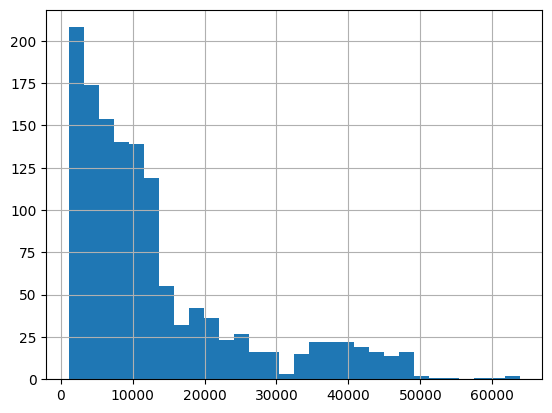

In [ ]:
df['charges'].hist(bins=30)
plt.show()

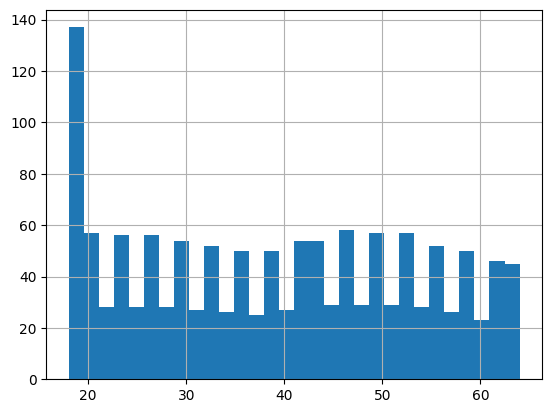

In [ ]:
df['age'].hist(bins=30)
plt.show()

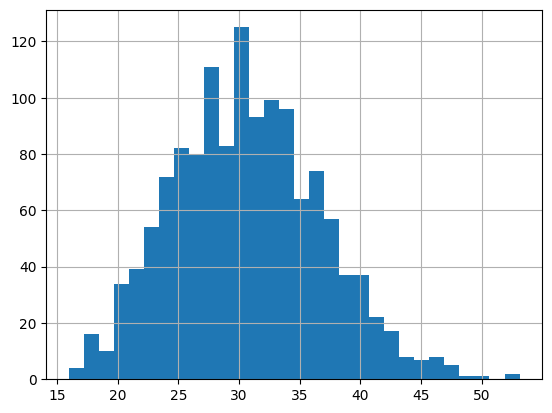

In [ ]:
df['bmi'].hist(bins=30)
plt.show()

In [ ]:
df['smokers'].hist(bins=30)

NameError: name 'df' is not defined

In [ ]:



df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})


df = pd.get_dummies(df, columns=['region'], drop_first=True)

print(df.head())
print(df.dtypes)

   age  sex     bmi  ...  region_northwest  region_southeast  region_southwest
0   19    0  27.900  ...             False             False              True
1   18    1  33.770  ...             False              True             False
2   28    1  33.000  ...             False              True             False
3   33    1  22.705  ...              True             False             False
4   32    1  28.880  ...              True             False             False

[5 rows x 9 columns]
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


In [ ]:
print(df.corr()['charges'].sort_values(ascending=False))

charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


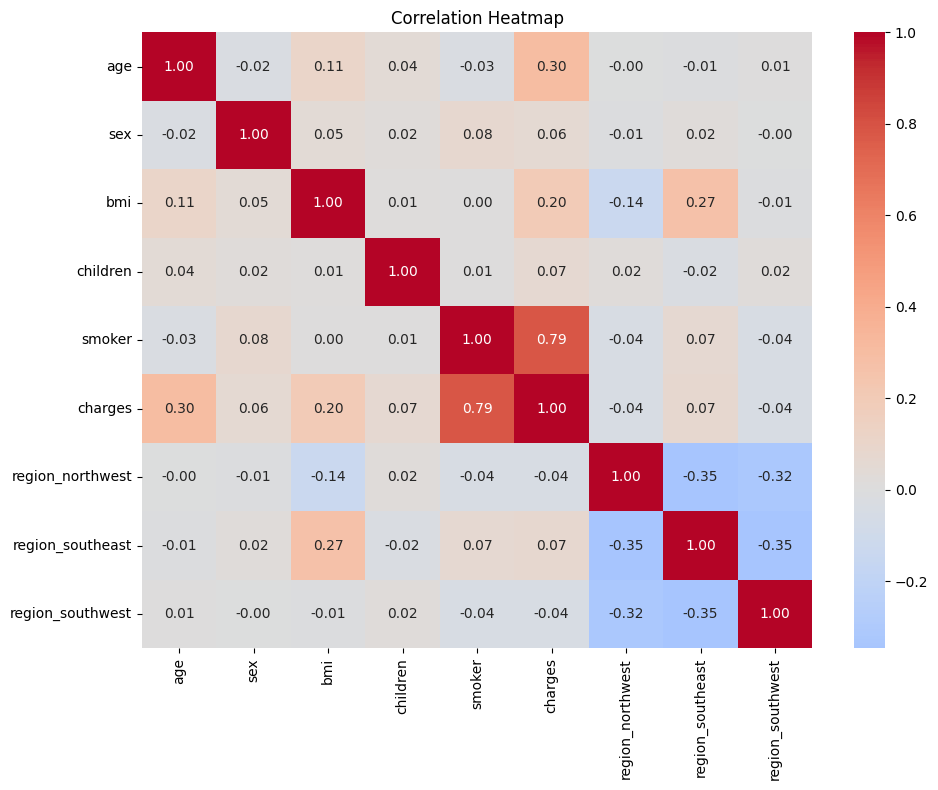

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

x= df.drop('charges',axis=1)
y = np.log1p(df['charges'])
train_X, test_X, train_Y, test_Y= train_test_split(x,y, test_size=0.2, random_state=42)
print('training set size: ',train_X)
print('test set size: ', test_X)

training set size:        age  sex     bmi  ...  region_northwest  region_southeast  region_southwest
560    46    0  19.950  ...              True             False             False
1285   47    0  24.320  ...             False             False             False
1142   52    0  24.860  ...             False              True             False
969    39    0  34.320  ...             False              True             False
486    54    0  21.470  ...              True             False             False
...   ...  ...     ...  ...               ...               ...               ...
1095   18    0  31.350  ...             False             False             False
1130   39    0  23.870  ...             False              True             False
1294   58    1  25.175  ...             False             False             False
860    37    0  47.600  ...             False             False              True
1126   55    1  29.900  ...             False             False              T

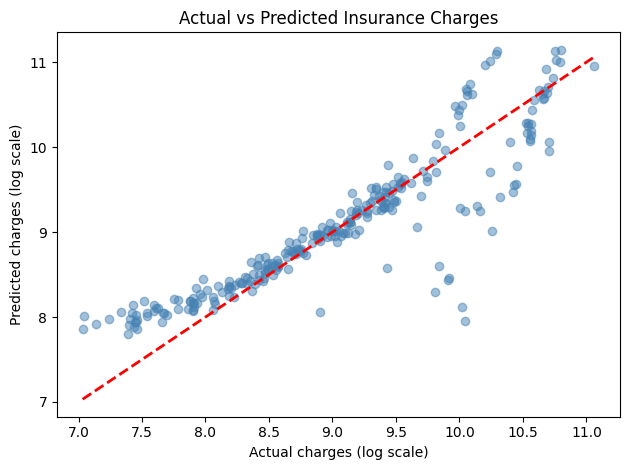

In [ ]:
from sklearn.linear_model import LinearRegression
insurance_model=LinearRegression()
insurance_model.fit(train_X, train_Y)
val_y=insurance_model.predict(test_X)
plt.scatter(test_Y, val_y,  alpha=0.5, color='steelblue')
plt.plot([test_Y.min(), test_Y.max()],
         [test_Y.min(), test_Y.max()], 'r--', lw=2)
plt.xlabel('Actual charges (log scale)')
plt.ylabel('Predicted charges (log scale)')
plt.title('Actual vs Predicted Insurance Charges')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
val_y_actual = np.expm1(val_y)
test_Y_actual = np.expm1(test_Y)

rmse=np.sqrt(mean_squared_error(test_Y_actual, val_y_actual))
mae=mean_absolute_error(test_Y_actual, val_y_actual)
r2=r2_score(test_Y_actual, val_y_actual)
metrics = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

RMSE: 7814.0640
MAE: 3888.4432
R²: 0.6067


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(train_X, train_Y)
rf_val_y=rf_model.predict(test_X)
rf_val_y_actual = np.expm1(rf_val_y)

rmse = np.sqrt(mean_squared_error(test_Y_actual, rf_val_y_actual))
mae  = mean_absolute_error(test_Y_actual, rf_val_y_actual)
r2   = r2_score(test_Y_actual, rf_val_y_actual)

metrics = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

RMSE: 4358.9730
MAE: 2088.5415
R²: 0.8776


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(train_X, train_Y)

xgb_val_y = xgb_model.predict(test_X)

xgb_val_y_actual = np.expm1(xgb_val_y)

rmse = np.sqrt(mean_squared_error(test_Y_actual, xgb_val_y_actual))
mae  = mean_absolute_error(test_Y_actual, xgb_val_y_actual)
r2   = r2_score(test_Y_actual, xgb_val_y_actual)

metrics = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

RMSE: 4722.7215
MAE: 2220.3452
R²: 0.8563


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(train_X, train_Y)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_.round(4))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R²: 0.8235


In [20]:
tuned_xgb = XGBRegressor(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42
)

tuned_xgb.fit(train_X, train_Y)

tuned_xgb_val_y = tuned_xgb.predict(test_X)


tuned_xgb_val_y_actual = np.expm1(tuned_xgb_val_y)

rmse = np.sqrt(mean_squared_error(test_Y_actual, tuned_xgb_val_y_actual))
mae  = mean_absolute_error(test_Y_actual, tuned_xgb_val_y_actual)
r2   = r2_score(test_Y_actual, tuned_xgb_val_y_actual)

metrics = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

RMSE: 4330.6351
MAE: 1939.0613
R²: 0.8792


In [22]:
from sklearn.model_selection import cross_val_score
import numpy as np


models = {
    'Linear Regression': insurance_model,
    'Random Forest': rf_model,
    'XGBoost Tuned': tuned_xgb
}

print("5-Fold Cross Validation Results")
print("=" * 45)

for name, model in models.items():
    scores = cross_val_score(
        model,
        x,
        y,
        cv=5,
        scoring='r2'
    )
    print(f"\n{name}")
    print(f"  Scores per fold : {scores.round(4)}")
    print(f"  Mean R²         : {scores.mean().round(4)}")
    print(f"  Std deviation   : {scores.std().round(4)}")

5-Fold Cross Validation Results

Linear Regression
  Scores per fold : [0.7983 0.6867 0.8313 0.7683 0.7343]
  Mean R²         : 0.7638
  Std deviation   : 0.0502

Random Forest
  Scores per fold : [0.8502 0.6963 0.8729 0.8262 0.7853]
  Mean R²         : 0.8061
  Std deviation   : 0.0621

XGBoost Tuned
  Scores per fold : [0.8847 0.7398 0.9002 0.8446 0.8137]
  Mean R²         : 0.8366
  Std deviation   : 0.0571


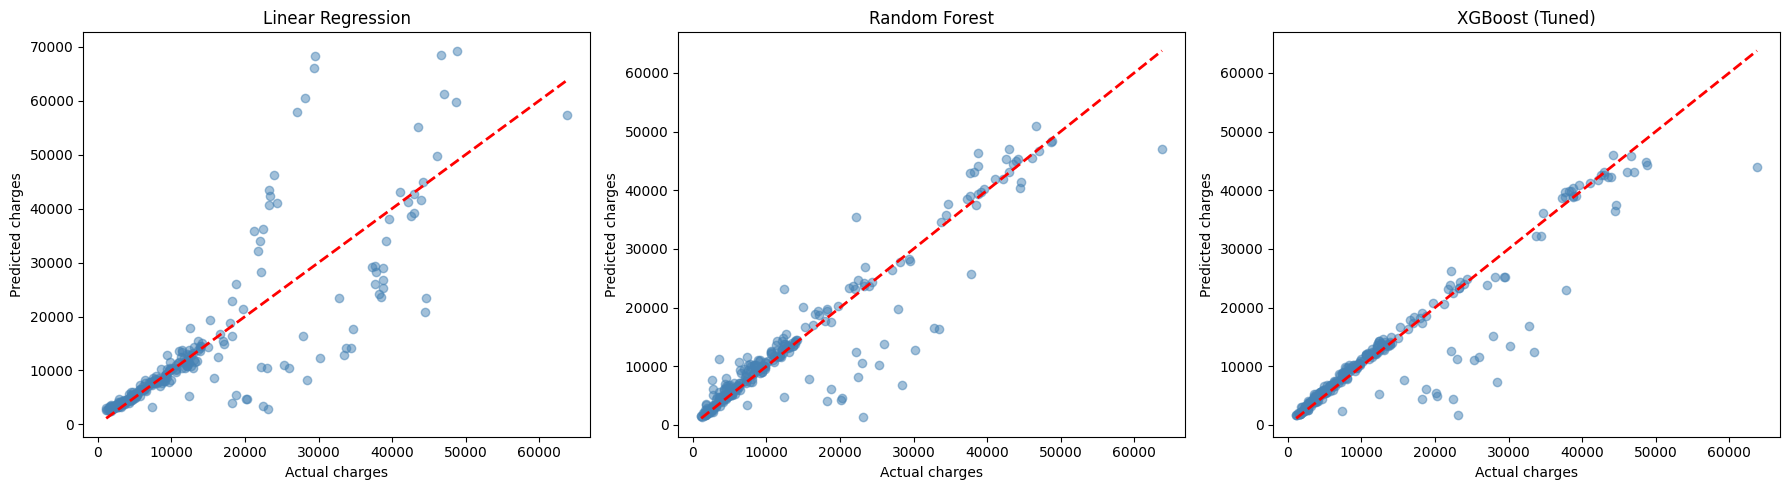

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Linear Regression': np.expm1(insurance_model.predict(test_X)),
    'Random Forest': rf_val_y_actual,
    'XGBoost (Tuned)': tuned_xgb_val_y_actual
}

for ax, (name, preds) in zip(axes, models.items()):
    ax.scatter(test_Y_actual, preds, alpha=0.5, color='steelblue')
    ax.plot([test_Y_actual.min(), test_Y_actual.max()],
            [test_Y_actual.min(), test_Y_actual.max()], 'r--', lw=2)
    ax.set_xlabel('Actual charges')
    ax.set_ylabel('Predicted charges')
    ax.set_title(name)

plt.tight_layout()
plt.show()

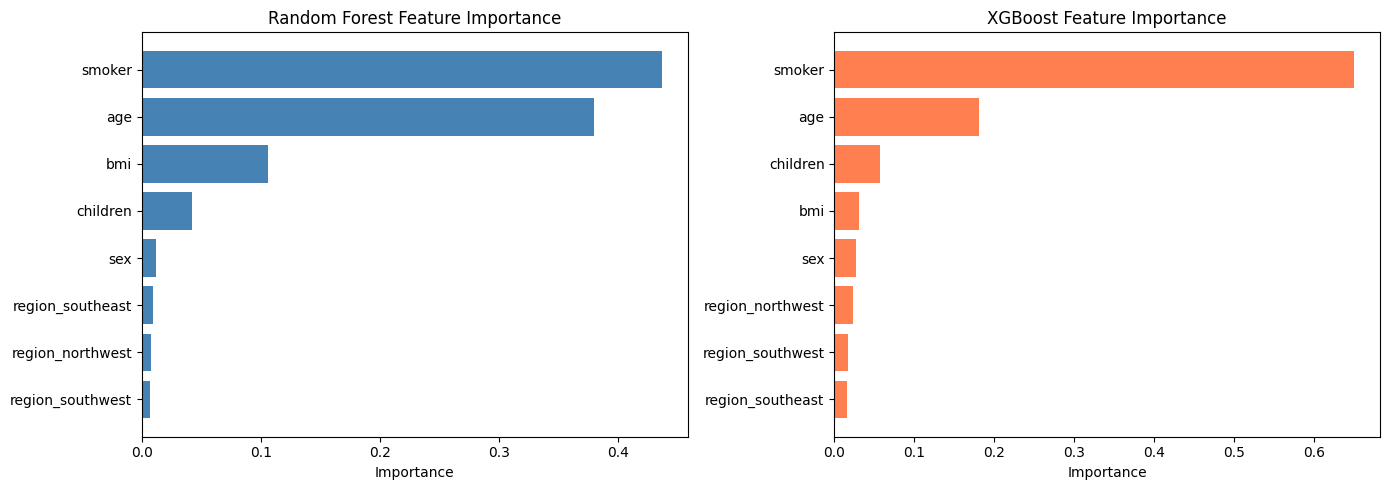

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


rf_importance = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')


xgb_importance = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': tuned_xgb.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color='coral')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()